##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise 

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

In [1]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

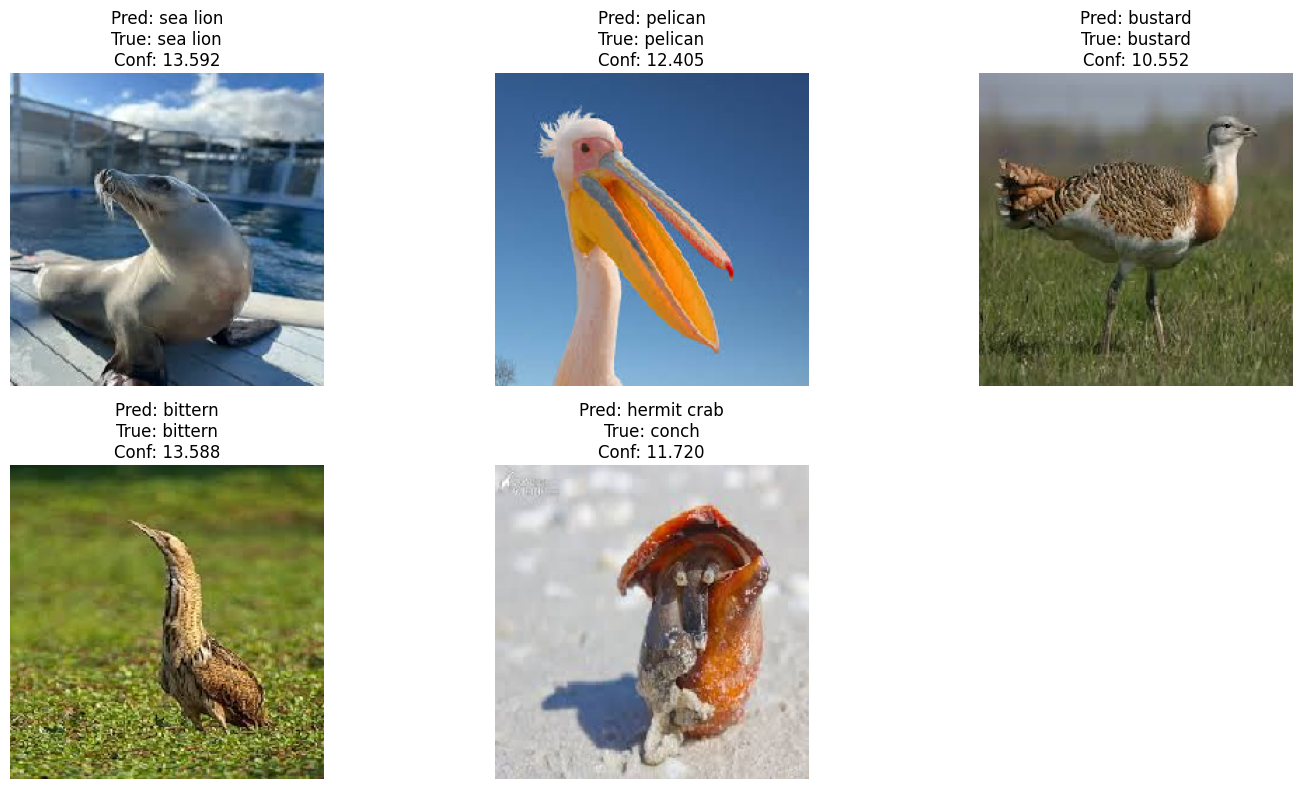

,Image File,Predicted Label,True Label (What you searched),Correct? (Yes/No),Confidence
0,image1.png,sea lion,sea lion,Yes,13.5921
1,image2.png,pelican,pelican,Yes,12.4046
2,image3.png,bustard,bustard,Yes,10.5521
3,image4.png,bittern,bittern,Yes,13.5881
4,image5.png,hermit crab,conch,No,11.7204


In [2]:
# Import libraries
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import keras_hub

# Load ImageNet class names
classes_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
imagenet_classes = requests.get(classes_url, timeout=30).text.strip().splitlines()

# Load ViT preprocessor and model
preset = "vit_base_patch16_224_imagenet"
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(preset)
model = keras_hub.models.ViTImageClassifier.from_preset(preset, preprocessor=None)

# Local image paths
image_paths = {
    "image1.png": "image1.png",
    "image2.png": "image2.png",
    "image3.png": "image3.png",
    "image4.png": "image4.png",
    "image5.png": "image5.png",
}

# True labels
true_labels = {
    "image1.png": "sea lion",
    "image2.png": "pelican",
    "image3.png": "bustard",
    "image4.png": "bittern",
    "image5.png": "conch",
}

# Check files exist
for k, p in image_paths.items():
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing: {p}")

# Load images
file_names = list(image_paths.keys())
images = []
display_images = []

for name in file_names:
    img = keras.utils.load_img(image_paths[name], target_size=(224, 224))
    arr = np.array(img, dtype=np.uint8)
    images.append(arr)
    display_images.append(arr)

images = np.array(images, dtype=np.uint8)

# Preprocess
x = preprocessor(images)

# Predict
preds = model.predict(x, verbose=0)

top1_idx = np.argmax(preds, axis=1)
predicted_labels = [imagenet_classes[i] for i in top1_idx]
confidences = [float(preds[n, i]) for n, i in enumerate(top1_idx)]

true_values = [true_labels[n] for n in file_names]
correct = [
    "Yes" if p.strip().lower() == t.strip().lower() else "No"
    for p, t in zip(predicted_labels, true_values)
]

# Show images and predictions
plt.figure(figsize=(15, 8))
for i, img in enumerate(display_images):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {true_values[i]}\nConf: {confidences[i]:.3f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Results table
results_df = pd.DataFrame({
    "Image File": file_names,
    "Predicted Label": predicted_labels,
    "True Label (What you searched)": true_values,
    "Correct? (Yes/No)": correct,
    "Confidence": np.round(confidences, 4),
})

results_df